# 03 — Modeling có hệ thống
## Loan Default Prediction | Give Me Some Credit

**Mục tiêu notebook này:**
Huấn luyện và so sánh 4 models theo thứ tự tăng dần độ phức tạp:
1. **Logistic Regression** — baseline, interpretable, odds ratios
2. **Decision Tree CART** — most visualizable, Gini/Entropy
3. **Random Forest** — Bagging + random features, variance reduction
4. **XGBoost** — Gradient Boosting, tốt nhất về AUC

**Protocol thống nhất cho mỗi model:**
- Stratified 5-Fold Cross-Validation
- Primary metric: **AUC-ROC** (imbalanced data, threshold-free)
- Hyperparameter tuning: `RandomizedSearchCV` (n_iter=15)
- Plots: Confusion Matrix, ROC curve, PR curve, Learning Curve
- Lý do không dùng Accuracy: model "predict all 0" đạt 93.32% Accuracy nhưng Recall = 0


## 0. Setup & Load Data

In [1]:
import sys, warnings, time, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV,
                                      cross_val_score, learning_curve)
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              roc_curve, precision_recall_curve,
                              average_precision_score)
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline as SkPipeline

# XGBoost
import xgboost as xgb

# SHAP
import shap

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10,
    'axes.titlesize': 11, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.grid': True, 'grid.alpha': 0.35,
})
PALETTE = {'default': '#e74c3c', 'non_default': '#2ecc71', 'neutral': '#3498db',
           'highlight': '#9b59b6'}
Path('../reports').mkdir(exist_ok=True)
Path('../models').mkdir(exist_ok=True)
print("Setup complete.")


Setup complete.


In [2]:
# ─── Load splits ─────────────────────────────────────────────────────────
TARGET = 'SeriousDlqin2yrs'

with open('../models/feature_metadata.json') as f:
    meta = json.load(f)
FEATURES = meta['feature_cols']

train_df = pd.read_csv('../data/splits/train.csv', index_col=0)
val_df   = pd.read_csv('../data/splits/val.csv',   index_col=0)
test_df  = pd.read_csv('../data/splits/test.csv',  index_col=0)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

# Scale_pos_weight for XGBoost
SPW = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Train: {X_train.shape} | positive rate: {y_train.mean()*100:.2f}%")
print(f"Val:   {X_val.shape}   | positive rate: {y_val.mean()*100:.2f}%")
print(f"Test:  {X_test.shape}  | positive rate: {y_test.mean()*100:.2f}%")
print(f"scale_pos_weight for XGBoost: {SPW:.2f}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Train: (104999, 14) | positive rate: 6.68%
Val:   (22500, 14)   | positive rate: 6.68%
Test:  (22500, 14)  | positive rate: 6.68%
scale_pos_weight for XGBoost: 13.96
Features (14): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'TotalDelinquencyScore', 'FinancialStressIndex', 'AbsoluteMonthlyDebt', 'DelinquencyTrend']


## 1. Helper Functions

In [3]:
# ─── Evaluation helpers ──────────────────────────────────────────────────
def evaluate_model(model, X, y, threshold=0.5, name='Model'):
    """Trả về dict các metrics tại một threshold cụ thể."""
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'Model': name,
        'AUC-ROC': roc_auc_score(y, proba),
        'Avg Precision': average_precision_score(y, proba),
        'F1': f1_score(y, pred, zero_division=0),
        'Precision': precision_score(y, pred, zero_division=0),
        'Recall': recall_score(y, pred, zero_division=0),
        'Threshold': threshold,
    }

def find_optimal_threshold(model, X_val, y_val):
    """Tìm threshold tối ưu theo F1 trên validation set."""
    proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 81)
    f1s = [f1_score(y_val, (proba >= t).astype(int), zero_division=0) for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    return best_t, max(f1s)

def plot_roc_pr(model, X, y, ax_roc, ax_pr, label, color):
    """Plot ROC và PR curve trên axes đã cho."""
    proba = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    auc = roc_auc_score(y, proba)
    ax_roc.plot(fpr, tpr, color=color, lw=1.8, label=f'{label} (AUC={auc:.4f})')

    prec, rec, _ = precision_recall_curve(y, proba)
    ap = average_precision_score(y, proba)
    ax_pr.plot(rec, prec, color=color, lw=1.8, label=f'{label} (AP={ap:.4f})')

def plot_confusion_matrix(model, X, y, ax, title, threshold=0.5):
    """Plot confusion matrix."""
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'],
                annot_kws={'size': 11})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title}\nTP={cm[1,1]:,} FP={cm[0,1]:,} FN={cm[1,0]:,} TN={cm[0,0]:,}')

# CV setup
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []   # Lưu kết quả tất cả models
print("Helpers ready. CV: StratifiedKFold(5)")


Helpers ready. CV: StratifiedKFold(5)


## 2. Logistic Regression — Baseline Interpretable Model

### Cơ sở toán học

**Mô hình:** Logistic Regression ánh xạ linear combination sang xác suất:

$$P(y=1 | \mathbf{x}) = \sigma(\mathbf{x}^\top \boldsymbol{\beta}) = \frac{1}{1 + e^{-\mathbf{x}^\top \boldsymbol{\beta}}}$$

**Log-odds (logit):** Lấy log của odds ratio:

$$\log\frac{P(y=1)}{P(y=0)} = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

**Tối ưu hóa — Maximum Likelihood Estimation (MLE):**

$$\mathcal{L}(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \log \sigma(\mathbf{x}_i^\top \boldsymbol{\beta}) + (1-y_i) \log(1 - \sigma(\mathbf{x}_i^\top \boldsymbol{\beta})) \right]$$

Gradient:
$$\frac{\partial \mathcal{L}}{\partial \boldsymbol{\beta}} = \mathbf{X}^\top (\boldsymbol{\sigma} - \mathbf{y})$$

**Regularization:**
- **L2 (Ridge):** $\mathcal{L} - \frac{1}{2C}\|\boldsymbol{\beta}\|^2_2$ — weight decay, smooth solution
- **L1 (Lasso):** $\mathcal{L} - \frac{1}{C}\|\boldsymbol{\beta}\|_1$ — sparse solution, auto feature selection

**Interpret coefficients:**
$e^{\beta_j}$ = odds ratio của feature $j$: khi $x_j$ tăng 1 đơn vị, odds của default nhân với $e^{\beta_j}$.

**Ý nghĩa trong credit scoring:** Logistic Regression coefficients cho phép giải thích trực tiếp tại sao một hồ sơ bị từ chối — yêu cầu của Basel III và Equal Credit Opportunity Act (ECOA).


In [4]:
# ─── Logistic Regression với sklearn Pipeline (scale inside) ─────────────
t0 = time.time()

# Pipeline: RobustScaler + LR (tree models không cần scale)
lr_pipeline = SkPipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='saga',   # Supports L1 + L2, fast for large datasets
    ))
])

# Hyperparameter search: C và penalty
param_dist_lr = {
    'lr__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'lr__penalty': ['l1', 'l2'],
}
rs_lr = RandomizedSearchCV(
    lr_pipeline, param_dist_lr, n_iter=12,
    scoring='roc_auc', cv=CV,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
rs_lr.fit(X_train, y_train)

lr_best = rs_lr.best_estimator_
train_time_lr = time.time() - t0

print(f"Best params: {rs_lr.best_params_}")
print(f"Best CV AUC-ROC: {rs_lr.best_score_:.4f}")
print(f"Train time: {train_time_lr:.1f}s")


Best params: {'lr__penalty': 'l1', 'lr__C': 0.001}
Best CV AUC-ROC: 0.8371
Train time: 487.9s


In [5]:
# ─── Evaluate LR ─────────────────────────────────────────────────────────
opt_t_lr, _ = find_optimal_threshold(lr_best, X_val, y_val)
res_lr_val  = evaluate_model(lr_best, X_val,   y_val,  opt_t_lr, 'LR (val)')
res_lr_test = evaluate_model(lr_best, X_test,  y_test, opt_t_lr, 'LR (test)')
results.append({**res_lr_test, 'CV_AUC': rs_lr.best_score_,
                'Train_time_s': round(train_time_lr, 1),
                'Optimal_threshold': round(opt_t_lr, 3)})

print(f"Val  AUC-ROC: {res_lr_val['AUC-ROC']:.4f} | F1: {res_lr_val['F1']:.4f}")
print(f"Test AUC-ROC: {res_lr_test['AUC-ROC']:.4f} | F1: {res_lr_test['F1']:.4f} @ threshold={opt_t_lr:.2f}")
print(f"Precision: {res_lr_test['Precision']:.4f} | Recall: {res_lr_test['Recall']:.4f}")


Val  AUC-ROC: 0.8388 | F1: 0.4259
Test AUC-ROC: 0.8432 | F1: 0.4340 @ threshold=0.66
Precision: 0.3878 | Recall: 0.4927


In [6]:
# ─── Odds Ratios & Domain Interpretation ─────────────────────────────────
scaler_ = lr_best.named_steps['scaler']
lr_     = lr_best.named_steps['lr']
coefs   = lr_.coef_[0]
odds_ratio = np.exp(coefs)

coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient (β)': coefs,
    'Odds Ratio (e^β)': odds_ratio,
}).sort_values('Odds Ratio (e^β)', ascending=False)

print("=== Odds Ratios — Domain Interpretation ===")
print(f"({'L1' if rs_lr.best_params_['lr__penalty']=='l1' else 'L2'} regularization, "
     f"C={rs_lr.best_params_['lr__C']})")
print()
print(coef_df.to_string(index=False))
print()
print("Top 3 risk factors (odds ratio > 1 = increases default probability):")
top3 = coef_df[coef_df['Odds Ratio (e^β)'] > 1].head(3)
for _, row in top3.iterrows():
    print(f"  {row['Feature']}: OR={row['Odds Ratio (e^β)']:.3f} → 1 đơn vị tăng → risk x{row['Odds Ratio (e^β)']:.2f}")


=== Odds Ratios — Domain Interpretation ===
(L1 regularization, C=0.001)

                             Feature  Coefficient (β)  Odds Ratio (e^β)
               TotalDelinquencyScore         0.255146          1.290650
RevolvingUtilizationOfUnsecuredLines         0.191428          1.210978
                FinancialStressIndex         0.170082          1.185403
NumberOfTime30-59DaysPastDueNotWorse         0.061833          1.063785
                    DelinquencyTrend         0.024627          1.024933
        NumberRealEstateLoansOrLines         0.005529          1.005544
NumberOfTime60-89DaysPastDueNotWorse         0.001802          1.001804
     NumberOfOpenCreditLinesAndLoans         0.000550          1.000550
                   AbsoluteMonthlyDebt         0.000000          1.000000
             NumberOfTimes90DaysLate         0.000000          1.000000
                           DebtRatio        -0.000140          0.999860
                  NumberOfDependents        -0.052353       

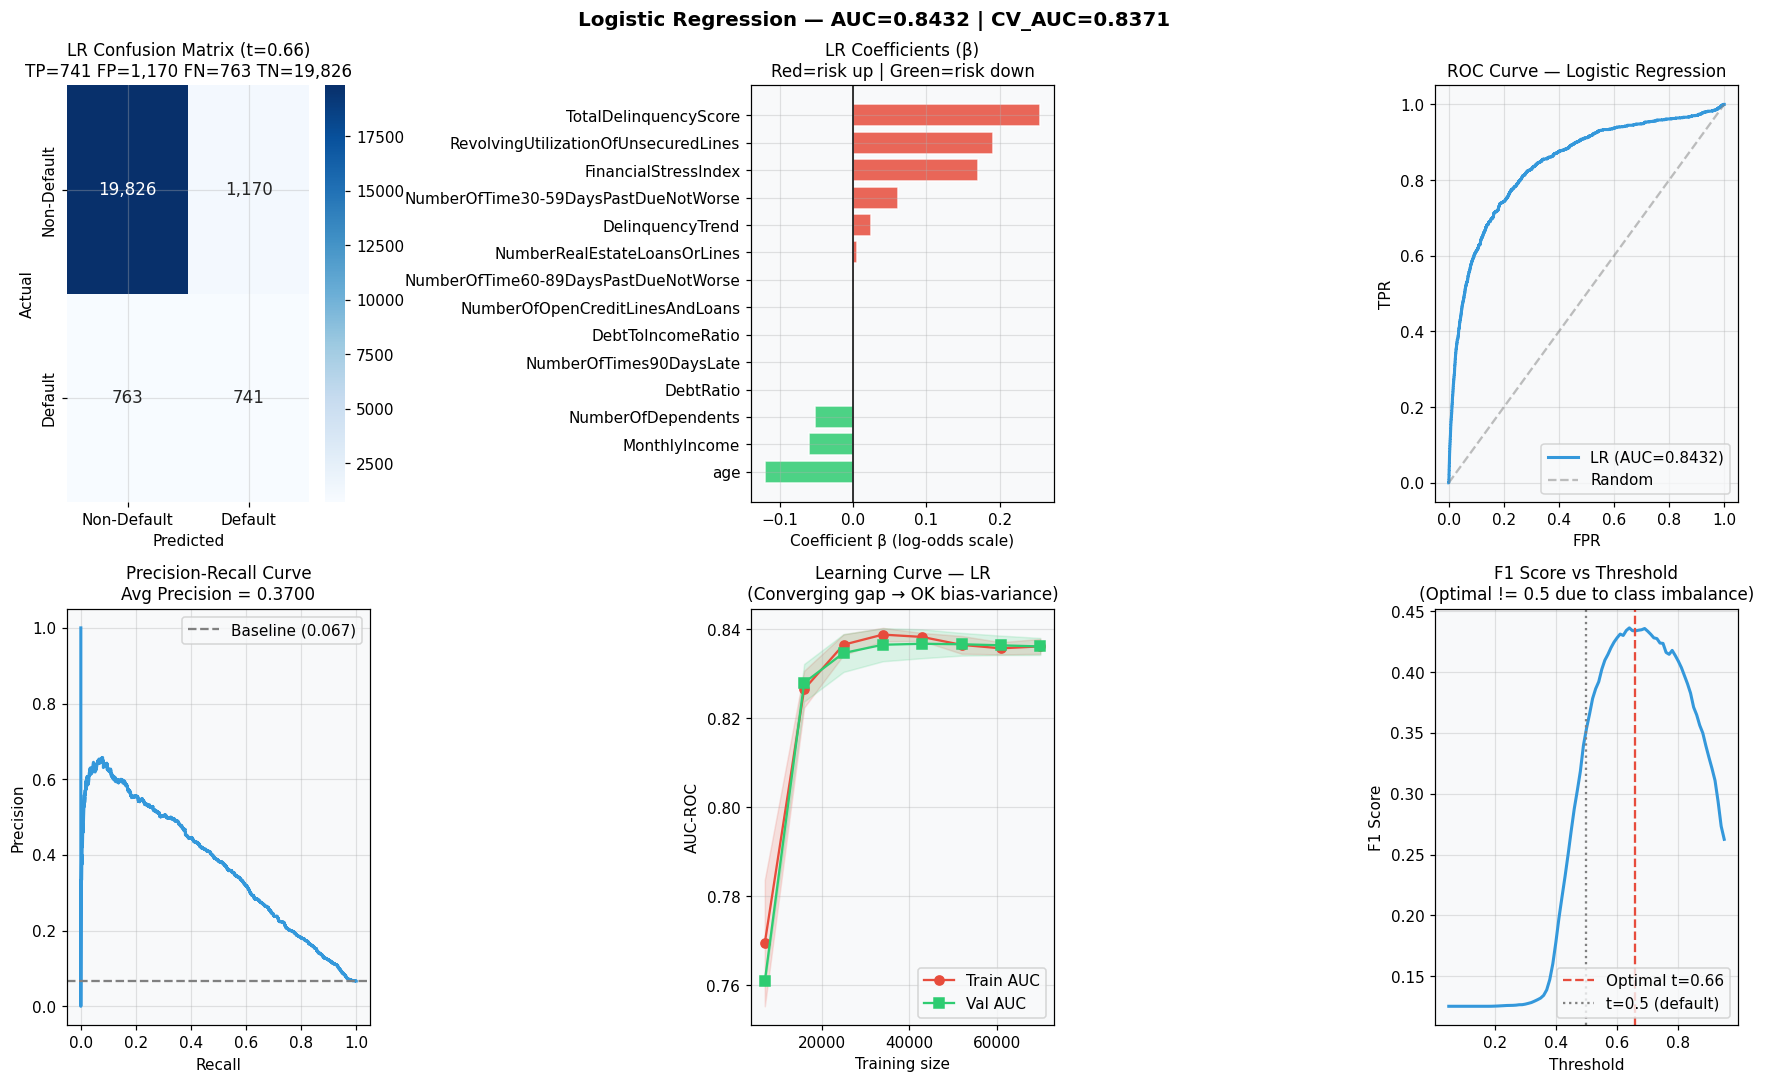

LR done. AUC=0.8432


In [7]:
# ─── LR Plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Confusion Matrix
plot_confusion_matrix(lr_best, X_test, y_test, axes[0, 0],
                      f'LR Confusion Matrix (t={opt_t_lr:.2f})', opt_t_lr)

# 2. Odds Ratio Plot
ax = axes[0, 1]
cd = coef_df.sort_values('Coefficient (β)')
colors = [PALETTE['default'] if v > 0 else PALETTE['non_default'] for v in cd['Coefficient (β)']]
ax.barh(cd['Feature'], cd['Coefficient (β)'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Coefficient β (log-odds scale)')
ax.set_title('LR Coefficients (β)\nRed=risk up | Green=risk down')

# 3. ROC + PR Curves
ax_roc = axes[0, 2]
proba_lr = lr_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_lr)
auc_lr = roc_auc_score(y_test, proba_lr)
ax_roc.plot(fpr, tpr, color=PALETTE['neutral'], lw=2, label=f'LR (AUC={auc_lr:.4f})')
ax_roc.plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC Curve — Logistic Regression')
ax_roc.legend()

# 4. PR Curve
ax = axes[1, 0]
prec, rec, _ = precision_recall_curve(y_test, proba_lr)
ap_lr = average_precision_score(y_test, proba_lr)
ax.plot(rec, prec, color=PALETTE['neutral'], lw=2)
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve\nAvg Precision = {ap_lr:.4f}')
ax.legend()

# 5. Learning Curve
ax = axes[1, 1]
train_sizes, train_scores, val_scores = learning_curve(
    lr_best, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)
ax.plot(train_sizes, train_scores.mean(1), 'o-', color=PALETTE['default'],
        label='Train AUC')
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1), alpha=0.15,
                color=PALETTE['default'])
ax.plot(train_sizes, val_scores.mean(1), 's-', color=PALETTE['non_default'],
        label='Val AUC')
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1), alpha=0.15,
                color=PALETTE['non_default'])
ax.set_xlabel('Training size'); ax.set_ylabel('AUC-ROC')
ax.set_title('Learning Curve — LR\n(Converging gap → OK bias-variance)')
ax.legend()

# 6. Threshold vs F1
ax = axes[1, 2]
thresholds = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_test, (proba_lr >= t).astype(int), zero_division=0) for t in thresholds]
ax.plot(thresholds, f1s, color=PALETTE['neutral'], lw=2)
ax.axvline(opt_t_lr, color=PALETTE['default'], linestyle='--',
           label=f'Optimal t={opt_t_lr:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='t=0.5 (default)')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs Threshold\n(Optimal != 0.5 due to class imbalance)')
ax.legend()

plt.suptitle(f'Logistic Regression — AUC={auc_lr:.4f} | CV_AUC={rs_lr.best_score_:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_16_lr_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"LR done. AUC={auc_lr:.4f}")


## 3. Decision Tree CART — Most Visualizable Model

### Cơ sở toán học

**CART (Classification And Regression Trees)** chọn split tại mỗi node bằng cách maximize **Information Gain**:

$$IG(D, j, t) = H(D) - \frac{|D_L|}{|D|} H(D_L) - \frac{|D_R|}{|D|} H(D_R)$$

Với **Gini Impurity** (mặc định CART):

$$G(D) = 1 - \sum_{k} p_k^2 = 1 - p_0^2 - p_1^2$$

Giải thích: $G = 0$ khi node hoàn toàn pure (tất cả cùng class); $G = 0.5$ khi balanced.

Với binary classification, Gini thường được ưu tiên hơn Entropy vì:
- Computational: không cần log calculation
- Theoretical: tương tự entropy về split quality trong hầu hết cases

**Pruning strategy:** Không dùng post-pruning phức tạp, thay bằng **pre-pruning** qua:
- `max_depth`: độ sâu tối đa → kiểm soát model complexity
- `min_samples_leaf`: số samples tối thiểu tại leaf → tránh overfit trên noise
- `class_weight='balanced'`: adjust split criterion theo imbalance ratio


In [8]:
t0 = time.time()

param_dist_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_leaf': [10, 20, 50, 100, 200],
    'min_samples_split': [20, 50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 0.5, 0.7],
}
dt_base = DecisionTreeClassifier(
    class_weight='balanced', random_state=RANDOM_STATE
)
rs_dt = RandomizedSearchCV(
    dt_base, param_dist_dt, n_iter=20,
    scoring='roc_auc', cv=CV,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
rs_dt.fit(X_train, y_train)

dt_best = rs_dt.best_estimator_
train_time_dt = time.time() - t0

print(f"Best params: {rs_dt.best_params_}")
print(f"Best CV AUC-ROC: {rs_dt.best_score_:.4f}")
print(f"Tree depth: {dt_best.get_depth()} | Leaves: {dt_best.get_n_leaves()}")
print(f"Train time: {train_time_dt:.1f}s")

opt_t_dt, _ = find_optimal_threshold(dt_best, X_val, y_val)
res_dt_test = evaluate_model(dt_best, X_test, y_test, opt_t_dt, 'DT (test)')
results.append({**res_dt_test, 'CV_AUC': rs_dt.best_score_,
                'Train_time_s': round(train_time_dt, 1),
                'Optimal_threshold': round(opt_t_dt, 3)})

print(f"Test AUC-ROC: {res_dt_test['AUC-ROC']:.4f} | F1: {res_dt_test['F1']:.4f}")
print(f"Precision: {res_dt_test['Precision']:.4f} | Recall: {res_dt_test['Recall']:.4f}")


Best params: {'min_samples_split': 20, 'min_samples_leaf': 200, 'max_features': 0.5, 'max_depth': 10, 'criterion': 'gini'}
Best CV AUC-ROC: 0.8509
Tree depth: 10 | Leaves: 168
Train time: 13.2s


Test AUC-ROC: 0.8579 | F1: 0.4314
Precision: 0.3991 | Recall: 0.4694


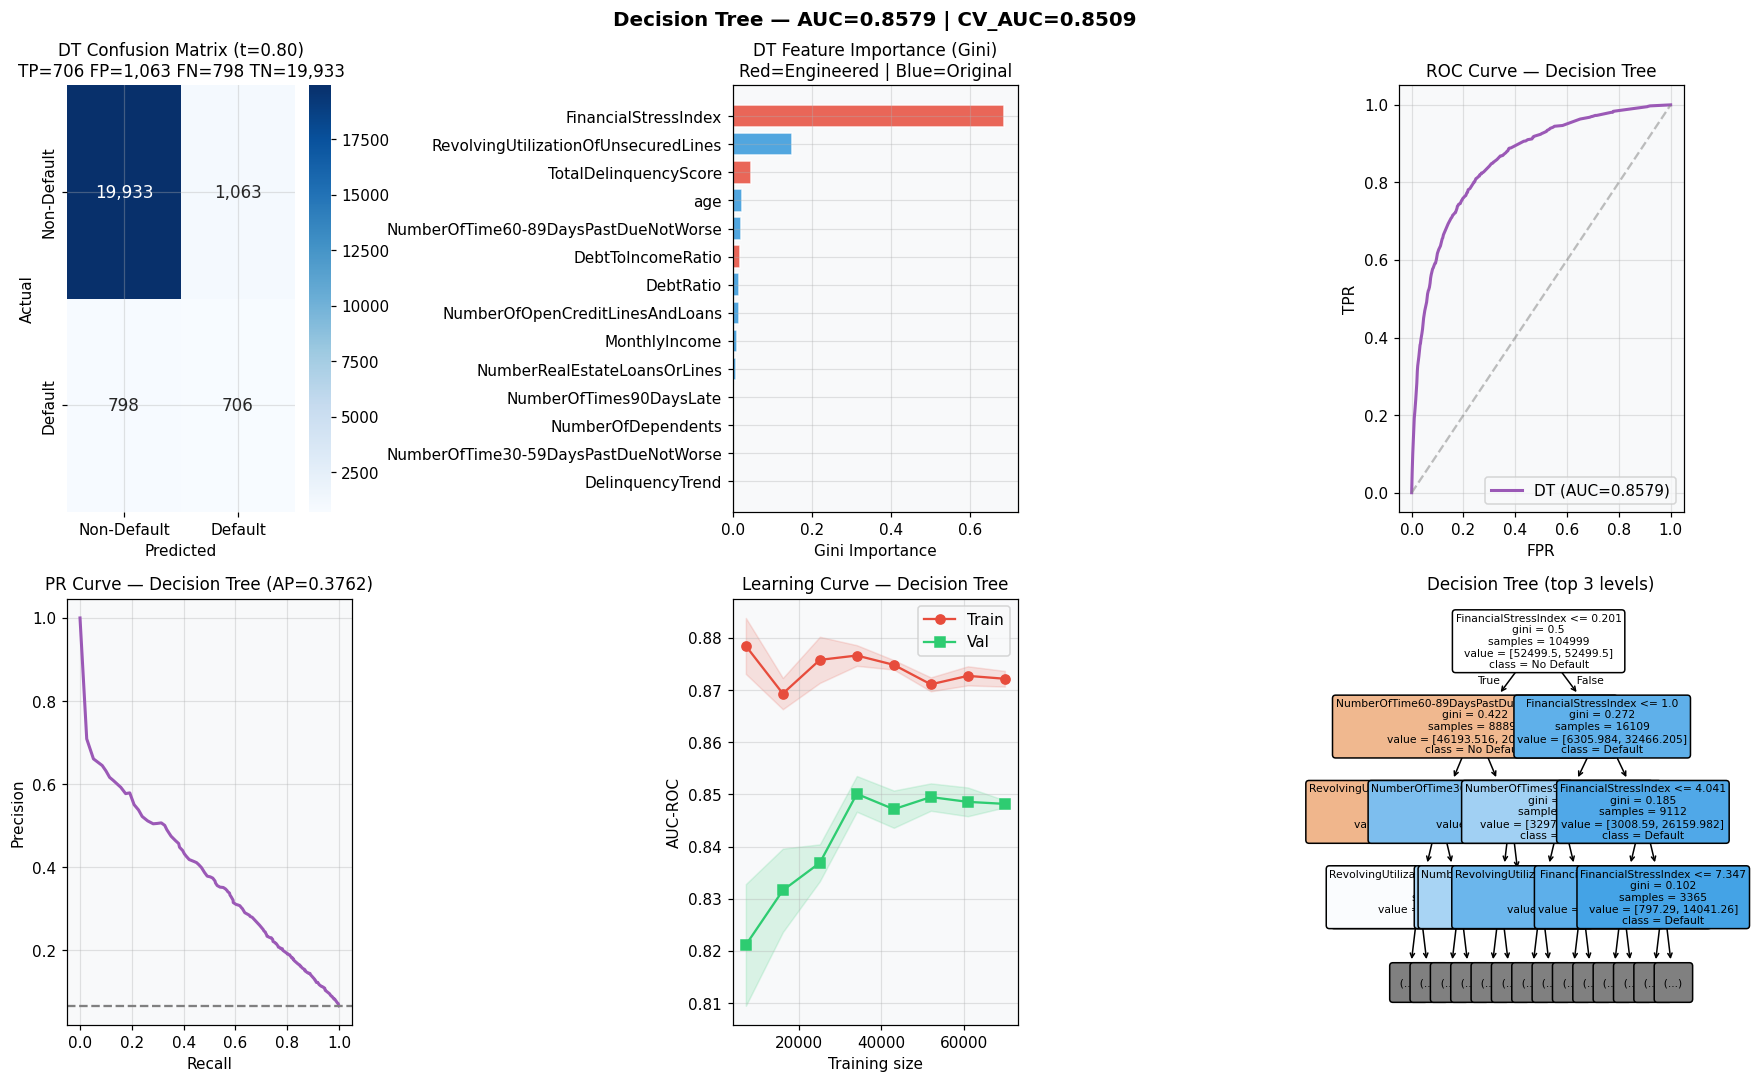

DT done. AUC=0.8579


In [9]:
# ─── DT Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Confusion Matrix
plot_confusion_matrix(dt_best, X_test, y_test, axes[0, 0],
                      f'DT Confusion Matrix (t={opt_t_dt:.2f})', opt_t_dt)

# 2. Feature Importance
ax = axes[0, 1]
imp_dt = pd.Series(dt_best.feature_importances_, index=FEATURES).sort_values()
colors = [PALETTE['default'] if f in meta['engineered_names'] else PALETTE['neutral']
          for f in imp_dt.index]
ax.barh(imp_dt.index, imp_dt.values, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Gini Importance')
ax.set_title('DT Feature Importance (Gini)\nRed=Engineered | Blue=Original')

# 3. ROC Curve
proba_dt = dt_best.predict_proba(X_test)[:, 1]
auc_dt = roc_auc_score(y_test, proba_dt)
fpr, tpr, _ = roc_curve(y_test, proba_dt)
axes[0, 2].plot(fpr, tpr, color=PALETTE['highlight'], lw=2, label=f'DT (AUC={auc_dt:.4f})')
axes[0, 2].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0, 2].set_xlabel('FPR'); axes[0, 2].set_ylabel('TPR')
axes[0, 2].set_title('ROC Curve — Decision Tree'); axes[0, 2].legend()

# 4. PR Curve
prec, rec, _ = precision_recall_curve(y_test, proba_dt)
ap_dt = average_precision_score(y_test, proba_dt)
axes[1, 0].plot(rec, prec, color=PALETTE['highlight'], lw=2)
axes[1, 0].axhline(y=y_test.mean(), color='gray', linestyle='--')
axes[1, 0].set_xlabel('Recall'); axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title(f'PR Curve — Decision Tree (AP={ap_dt:.4f})')

# 5. Learning Curve
train_sizes, tr_sc, vl_sc = learning_curve(
    dt_best, X_train, y_train,
    train_sizes=np.linspace(0.1,1.0,8), cv=StratifiedKFold(3,shuffle=True,random_state=42),
    scoring='roc_auc', n_jobs=-1
)
axes[1, 1].plot(train_sizes, tr_sc.mean(1), 'o-', color=PALETTE['default'], label='Train')
axes[1, 1].fill_between(train_sizes, tr_sc.mean(1)-tr_sc.std(1), tr_sc.mean(1)+tr_sc.std(1),
                         alpha=0.15, color=PALETTE['default'])
axes[1, 1].plot(train_sizes, vl_sc.mean(1), 's-', color=PALETTE['non_default'], label='Val')
axes[1, 1].fill_between(train_sizes, vl_sc.mean(1)-vl_sc.std(1), vl_sc.mean(1)+vl_sc.std(1),
                         alpha=0.15, color=PALETTE['non_default'])
axes[1, 1].set_xlabel('Training size'); axes[1, 1].set_ylabel('AUC-ROC')
axes[1, 1].set_title('Learning Curve — Decision Tree'); axes[1, 1].legend()

# 6. Tree visualization (depth ≤ 3 for readability)
ax = axes[1, 2]
plot_tree(dt_best, max_depth=3, feature_names=FEATURES,
          class_names=['No Default', 'Default'],
          filled=True, rounded=True, ax=ax, fontsize=7)
ax.set_title('Decision Tree (top 3 levels)')

plt.suptitle(f'Decision Tree — AUC={auc_dt:.4f} | CV_AUC={rs_dt.best_score_:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_17_dt_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"DT done. AUC={auc_dt:.4f}")


## 4. Random Forest — Bagging + Random Feature Subsampling

### Cơ sở toán học

**Bagging (Bootstrap Aggregating):** Với B bootstrap samples $D^{(b)}$ (sampling with replacement từ $D$):

$$\hat{f}_{\text{RF}}(x) = \frac{1}{B} \sum_{b=1}^{B} f^{(b)}(x)$$

**Variance Reduction:** Nếu B trees có variance $\sigma^2$ và pairwise correlation $\rho$:

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^B f^{(b)}(x)\right) = \rho \sigma^2 + \frac{1-\rho}{B} \sigma^2$$

Khi B → ∞: variance → $\rho \sigma^2$. Để minimize variance cần minimize $\rho$ — đây là lý do Random Forest dùng **Random Feature Subsampling**: tại mỗi split chỉ xem xét $\sqrt{p}$ features (thay vì tất cả $p$), làm giảm tương quan giữa các trees.

**Bias-Variance tradeoff:**
- Một cây sâu (deep tree): low bias, high variance → overfit
- RF trung bình nhiều cây: low bias (cây vẫn sâu), lower variance → generalizes tốt hơn

**OOB Error:** Mỗi bootstrap sample bỏ qua ~37% data gốc (out-of-bag). Những samples này có thể dùng để estimate generalization error mà không cần validation set riêng:
$$\text{OOB error} = \frac{1}{n} \sum_{i=1}^n \mathbf{1}[\hat{y}_i^{\text{OOB}} \neq y_i]$$


In [10]:
t0 = time.time()

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'max_features': ['sqrt', 0.3, 0.5],
    'min_samples_leaf': [5, 10, 20, 30],
    'min_samples_split': [10, 20, 50],
}
rf_base = RandomForestClassifier(
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rs_rf = RandomizedSearchCV(
    rf_base, param_dist_rf, n_iter=15,
    scoring='roc_auc', cv=CV,
    n_jobs=1,   # RF đã dùng n_jobs=-1 internally, tránh nested parallelism
    random_state=RANDOM_STATE, verbose=1,
)
rs_rf.fit(X_train, y_train)

rf_best = rs_rf.best_estimator_
train_time_rf = time.time() - t0

print(f"Best params: {rs_rf.best_params_}")
print(f"Best CV AUC-ROC: {rs_rf.best_score_:.4f}")
print(f"OOB Score (AUC proxy): {rf_best.oob_score_:.4f}")
print(f"Train time: {train_time_rf:.1f}s")

opt_t_rf, _ = find_optimal_threshold(rf_best, X_val, y_val)
res_rf_test = evaluate_model(rf_best, X_test, y_test, opt_t_rf, 'RF (test)')
results.append({**res_rf_test, 'CV_AUC': rs_rf.best_score_,
                'Train_time_s': round(train_time_rf, 1),
                'Optimal_threshold': round(opt_t_rf, 3)})

print(f"Test AUC-ROC: {res_rf_test['AUC-ROC']:.4f} | F1: {res_rf_test['F1']:.4f}")
print(f"Precision: {res_rf_test['Precision']:.4f} | Recall: {res_rf_test['Recall']:.4f}")


Fitting 5 folds for each of 15 candidates, totalling 75 fits


Best params: {'n_estimators': 200, 'min_samples_split': 50, 'min_samples_leaf': 30, 'max_features': 0.3, 'max_depth': 10}
Best CV AUC-ROC: 0.8635
OOB Score (AUC proxy): 0.8286
Train time: 511.4s


Test AUC-ROC: 0.8703 | F1: 0.4439
Precision: 0.3869 | Recall: 0.5206


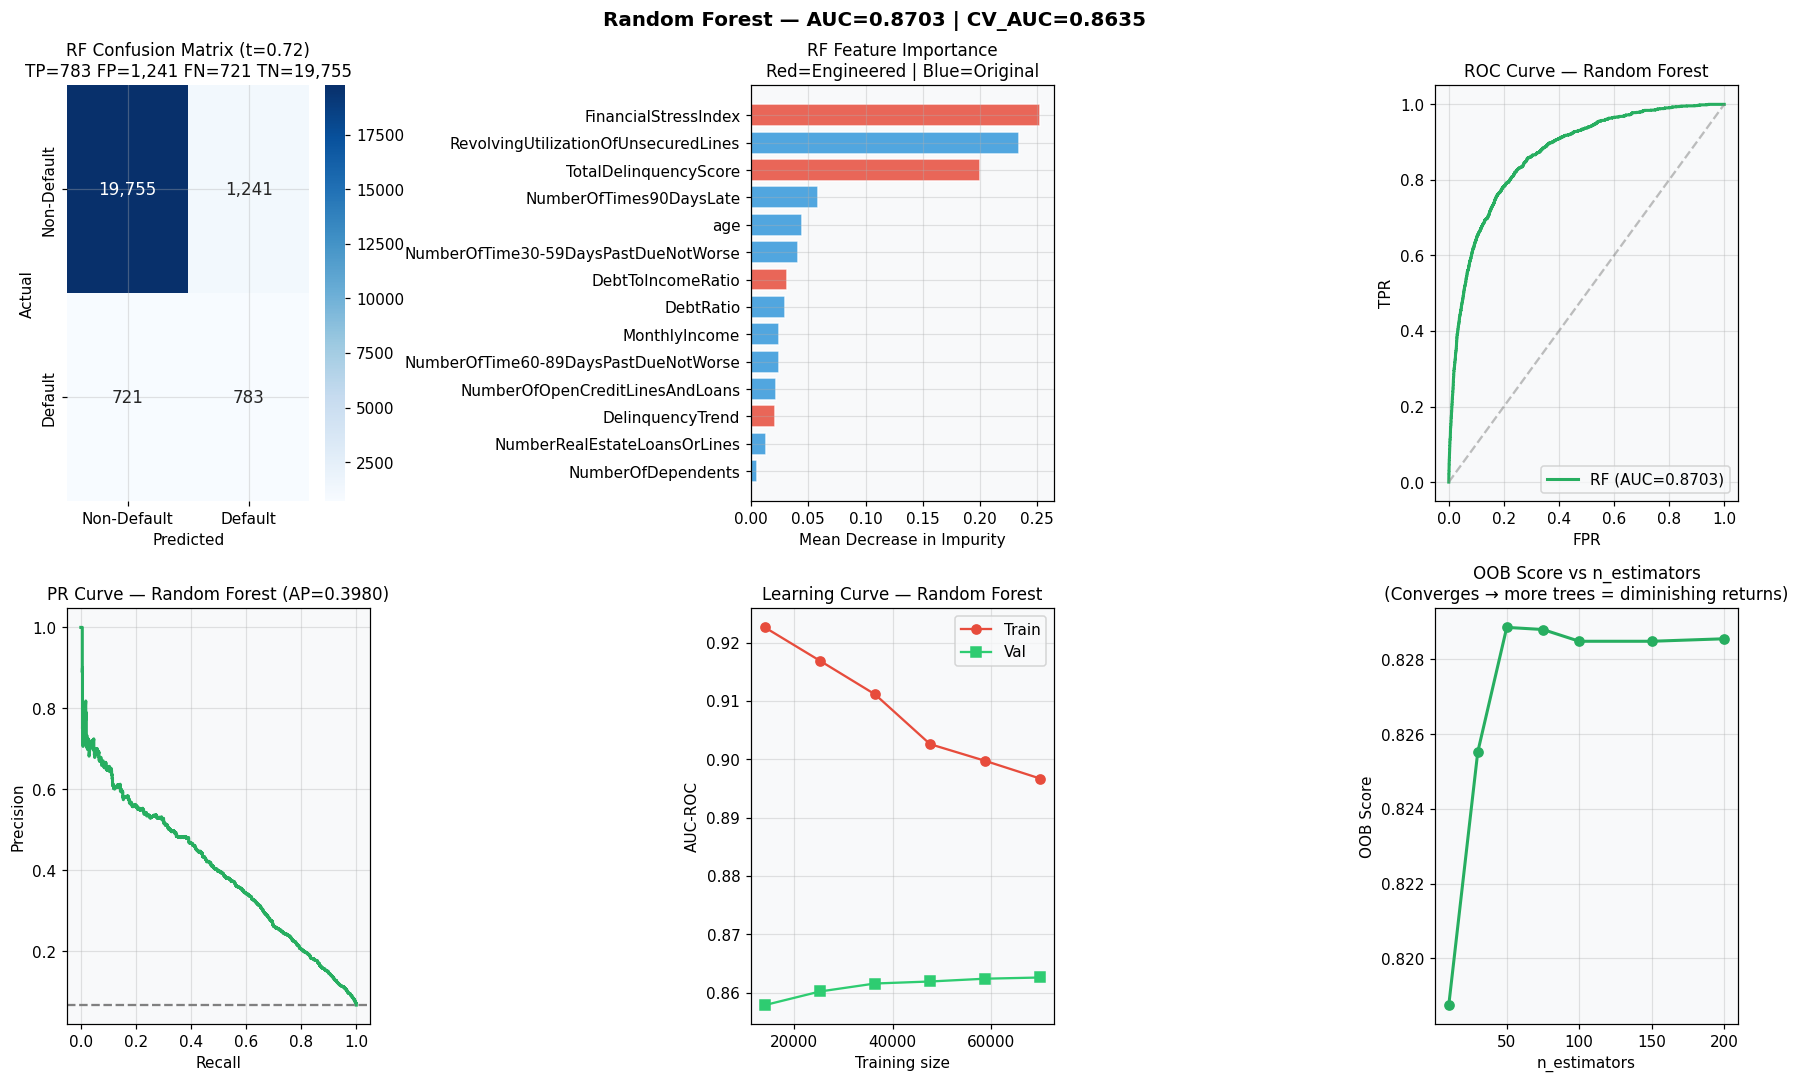

RF done. AUC=0.8703


In [11]:
# ─── RF Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Confusion Matrix
plot_confusion_matrix(rf_best, X_test, y_test, axes[0, 0],
                      f'RF Confusion Matrix (t={opt_t_rf:.2f})', opt_t_rf)

# 2. Feature Importance
ax = axes[0, 1]
imp_rf = pd.Series(rf_best.feature_importances_, index=FEATURES).sort_values()
colors = [PALETTE['default'] if f in meta['engineered_names'] else PALETTE['neutral']
          for f in imp_rf.index]
ax.barh(imp_rf.index, imp_rf.values, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('RF Feature Importance\nRed=Engineered | Blue=Original')

# 3. ROC Curve
proba_rf = rf_best.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, proba_rf)
fpr, tpr, _ = roc_curve(y_test, proba_rf)
axes[0, 2].plot(fpr, tpr, color='#27ae60', lw=2, label=f'RF (AUC={auc_rf:.4f})')
axes[0, 2].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0, 2].set_xlabel('FPR'); axes[0, 2].set_ylabel('TPR')
axes[0, 2].set_title('ROC Curve — Random Forest'); axes[0, 2].legend()

# 4. PR Curve
prec, rec, _ = precision_recall_curve(y_test, proba_rf)
ap_rf = average_precision_score(y_test, proba_rf)
axes[1, 0].plot(rec, prec, color='#27ae60', lw=2)
axes[1, 0].axhline(y=y_test.mean(), color='gray', linestyle='--')
axes[1, 0].set_xlabel('Recall'); axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title(f'PR Curve — Random Forest (AP={ap_rf:.4f})')

# 5. Learning Curve
train_sizes, tr_sc, vl_sc = learning_curve(
    rf_best, X_train, y_train,
    train_sizes=np.linspace(0.2,1.0,6), cv=StratifiedKFold(3,shuffle=True,random_state=42),
    scoring='roc_auc', n_jobs=-1
)
axes[1, 1].plot(train_sizes, tr_sc.mean(1), 'o-', color=PALETTE['default'], label='Train')
axes[1, 1].plot(train_sizes, vl_sc.mean(1), 's-', color=PALETTE['non_default'], label='Val')
axes[1, 1].set_xlabel('Training size'); axes[1, 1].set_ylabel('AUC-ROC')
axes[1, 1].set_title('Learning Curve — Random Forest'); axes[1, 1].legend()

# 6. n_estimators vs OOB AUC
ax = axes[1, 2]
oob_scores = []
n_est_range = [10, 30, 50, 75, 100, 150, 200]
for n in n_est_range:
    rf_tmp = RandomForestClassifier(
        n_estimators=n, oob_score=True, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE,
        **{k: v for k, v in rs_rf.best_params_.items() if k != 'n_estimators'}
    )
    rf_tmp.fit(X_train, y_train)
    oob_scores.append(rf_tmp.oob_score_)
ax.plot(n_est_range, oob_scores, 'o-', color='#27ae60', lw=2)
ax.set_xlabel('n_estimators'); ax.set_ylabel('OOB Score')
ax.set_title('OOB Score vs n_estimators\n(Converges → more trees = diminishing returns)')

plt.suptitle(f'Random Forest — AUC={auc_rf:.4f} | CV_AUC={rs_rf.best_score_:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_18_rf_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"RF done. AUC={auc_rf:.4f}")


## 5. XGBoost — Gradient Boosting với Regularization

### Cơ sở toán học

**Additive model:** XGBoost xây dựng ensemble additive:

$$\hat{y}_i = F_T(x_i) = \sum_{t=1}^{T} f_t(x_i)$$

Tại iteration $t$, thêm tree $f_t$ để minimize objective:

$$\mathcal{L}^{(t)} = \sum_{i=1}^n l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$

**Second-order Taylor approximation:**

$$\mathcal{L}^{(t)} \approx \sum_{i=1}^n \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$$

Trong đó $g_i = \partial_{\hat{y}^{(t-1)}} l$, $h_i = \partial^2_{\hat{y}^{(t-1)}} l$ là gradient và Hessian.

**Regularization term:**

$$\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^T w_j^2 + \alpha \sum_{j=1}^T |w_j|$$

- $\gamma$: min gain cần có để split (prune leaves với info gain thấp)
- $\lambda$: L2 trên leaf weights (weight decay)
- $\alpha$: L1 trên leaf weights (sparsity)

**Imbalanced data:** `scale_pos_weight = n_neg/n_pos = 13.96` → tăng trọng số class minority trong gradient calculation.

**Lợi thế so với Random Forest:**
- Boosting reduce bias (RF reduce variance)
- Second-order optimization → faster convergence
- Built-in regularization at tree level → ít overfit hơn gradient boosting thuần


In [12]:
t0 = time.time()

param_dist_xgb = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5],
}
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=SPW,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',   # Fast histogram-based tree building
)
rs_xgb = RandomizedSearchCV(
    xgb_base, param_dist_xgb, n_iter=15,
    scoring='roc_auc', cv=CV,
    n_jobs=1, random_state=RANDOM_STATE, verbose=1,
)
rs_xgb.fit(X_train, y_train)

xgb_best = rs_xgb.best_estimator_
train_time_xgb = time.time() - t0

print(f"Best params: {rs_xgb.best_params_}")
print(f"Best CV AUC-ROC: {rs_xgb.best_score_:.4f}")
print(f"Train time: {train_time_xgb:.1f}s")

opt_t_xgb, _ = find_optimal_threshold(xgb_best, X_val, y_val)
res_xgb_test = evaluate_model(xgb_best, X_test, y_test, opt_t_xgb, 'XGB (test)')
results.append({**res_xgb_test, 'CV_AUC': rs_xgb.best_score_,
                'Train_time_s': round(train_time_xgb, 1),
                'Optimal_threshold': round(opt_t_xgb, 3)})

print(f"Test AUC-ROC: {res_xgb_test['AUC-ROC']:.4f} | F1: {res_xgb_test['F1']:.4f}")
print(f"Precision: {res_xgb_test['Precision']:.4f} | Recall: {res_xgb_test['Recall']:.4f}")


Fitting 5 folds for each of 15 candidates, totalling 75 fits


Best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV AUC-ROC: 0.8656
Train time: 126.6s


Test AUC-ROC: 0.8714 | F1: 0.4466
Precision: 0.3937 | Recall: 0.5160


In [13]:
# ─── SHAP Analysis ───────────────────────────────────────────────────────
print("Computing SHAP values (TreeExplainer)...")
explainer = shap.TreeExplainer(xgb_best)
# Dùng 2000 samples để tiết kiệm thời gian
idx_sample = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
X_shap = X_test.iloc[idx_sample].values
shap_values = explainer.shap_values(X_shap)
print(f"SHAP values shape: {shap_values.shape}")


Computing SHAP values (TreeExplainer)...


SHAP values shape: (2000, 14)


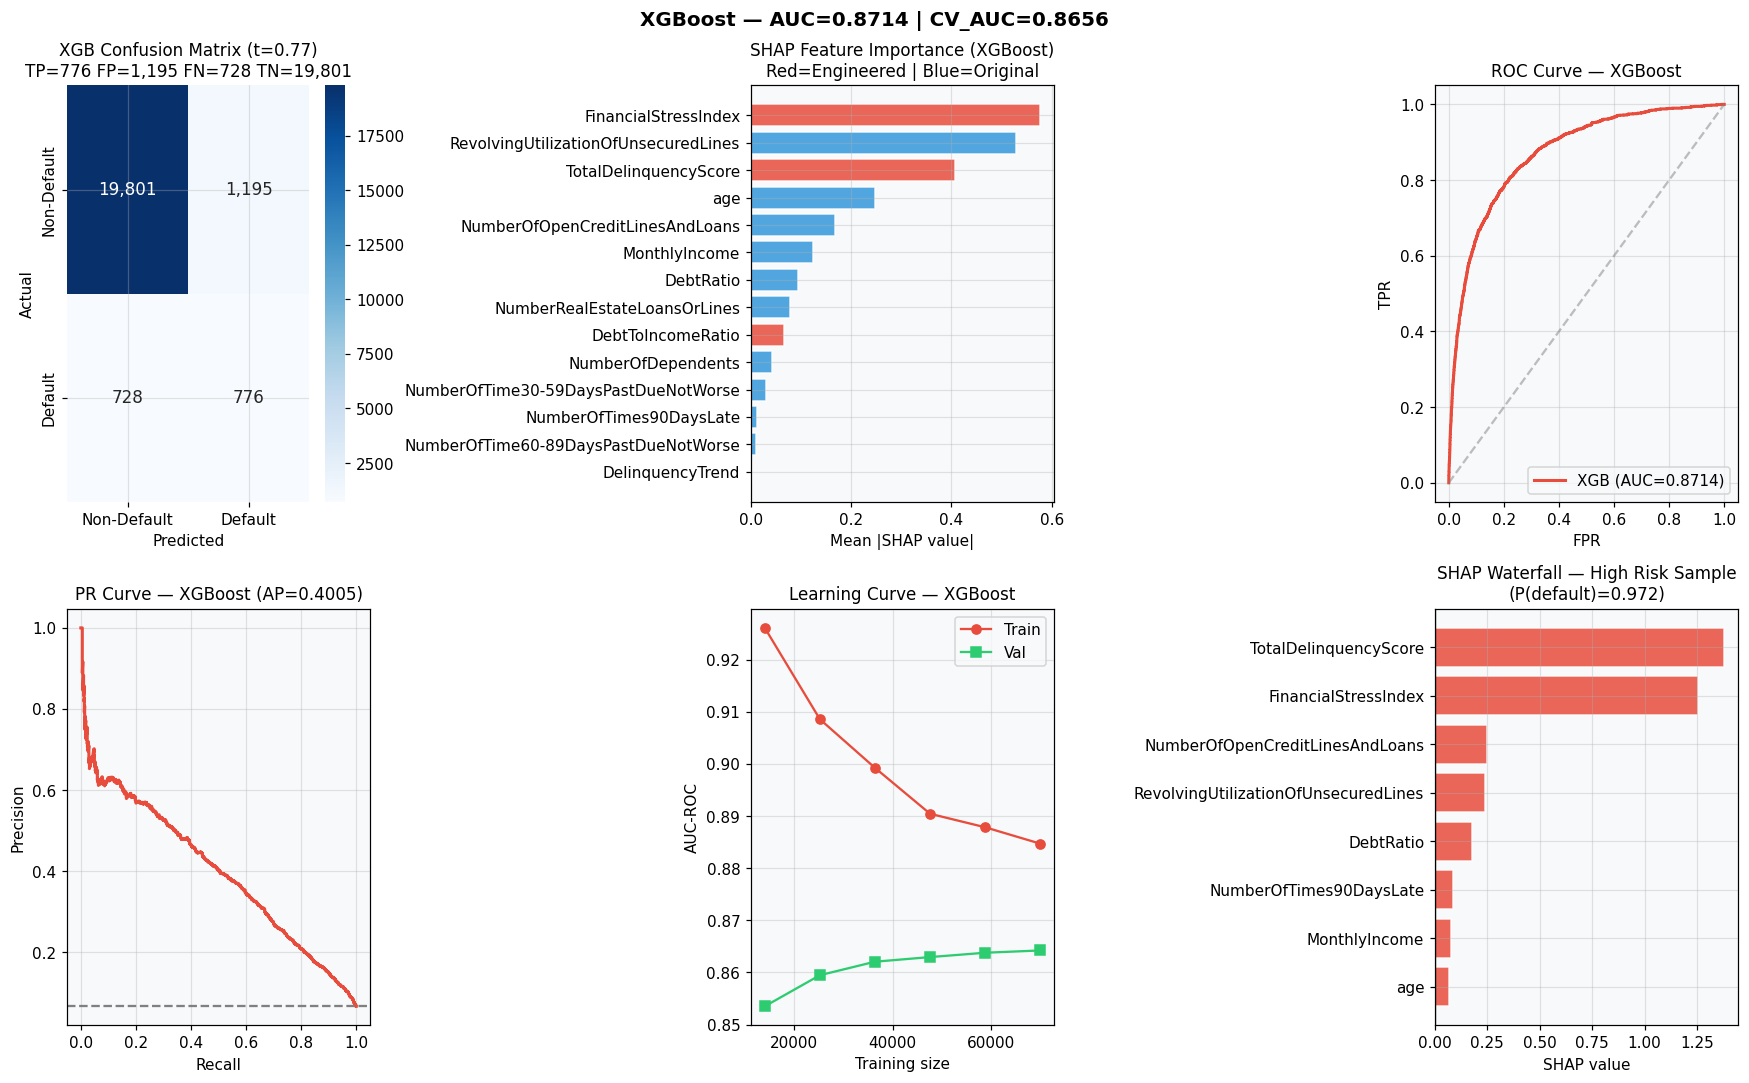

XGBoost done. AUC=0.8714


In [14]:
# ─── XGB Plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Confusion Matrix
plot_confusion_matrix(xgb_best, X_test, y_test, axes[0, 0],
                      f'XGB Confusion Matrix (t={opt_t_xgb:.2f})', opt_t_xgb)

# 2. SHAP Summary (Feature Importance)
ax = axes[0, 1]
shap_mean = np.abs(shap_values).mean(0)
shap_df = pd.Series(shap_mean, index=FEATURES).sort_values()
colors_shap = [PALETTE['default'] if f in meta['engineered_names'] else PALETTE['neutral']
               for f in shap_df.index]
ax.barh(shap_df.index, shap_df.values, color=colors_shap, alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance (XGBoost)\nRed=Engineered | Blue=Original')

# 3. ROC Curve
proba_xgb = xgb_best.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, proba_xgb)
fpr, tpr, _ = roc_curve(y_test, proba_xgb)
axes[0, 2].plot(fpr, tpr, color=PALETTE['default'], lw=2, label=f'XGB (AUC={auc_xgb:.4f})')
axes[0, 2].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0, 2].set_xlabel('FPR'); axes[0, 2].set_ylabel('TPR')
axes[0, 2].set_title('ROC Curve — XGBoost'); axes[0, 2].legend()

# 4. PR Curve
prec, rec, _ = precision_recall_curve(y_test, proba_xgb)
ap_xgb = average_precision_score(y_test, proba_xgb)
axes[1, 0].plot(rec, prec, color=PALETTE['default'], lw=2)
axes[1, 0].axhline(y=y_test.mean(), color='gray', linestyle='--')
axes[1, 0].set_xlabel('Recall'); axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title(f'PR Curve — XGBoost (AP={ap_xgb:.4f})')

# 5. Learning Curve
train_sizes, tr_sc, vl_sc = learning_curve(
    xgb_best, X_train, y_train,
    train_sizes=np.linspace(0.2,1.0,6), cv=StratifiedKFold(3,shuffle=True,random_state=42),
    scoring='roc_auc', n_jobs=-1
)
axes[1, 1].plot(train_sizes, tr_sc.mean(1), 'o-', color=PALETTE['default'], label='Train')
axes[1, 1].plot(train_sizes, vl_sc.mean(1), 's-', color=PALETTE['non_default'], label='Val')
axes[1, 1].set_xlabel('Training size'); axes[1, 1].set_ylabel('AUC-ROC')
axes[1, 1].set_title('Learning Curve — XGBoost'); axes[1, 1].legend()

# 6. SHAP waterfall for 1 high-risk prediction
ax = axes[1, 2]
proba_sample = xgb_best.predict_proba(X_test.iloc[idx_sample])[:, 1]
high_risk_local = np.argmax(proba_sample)
shap_single = shap_values[high_risk_local]
shap_abs = np.abs(shap_single)
top_k = 8
top_idx = np.argsort(shap_abs)[-top_k:]
top_features = [FEATURES[i] for i in top_idx]
top_shap = shap_single[top_idx]
colors_bar = [PALETTE['default'] if v > 0 else PALETTE['non_default'] for v in top_shap]
ax.barh(top_features, top_shap, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('SHAP value')
ax.set_title(f'SHAP Waterfall — High Risk Sample\n(P(default)={proba_sample[high_risk_local]:.3f})')

plt.suptitle(f'XGBoost — AUC={auc_xgb:.4f} | CV_AUC={rs_xgb.best_score_:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_19_xgb_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"XGBoost done. AUC={auc_xgb:.4f}")


## 6. So sánh tổng hợp — Model Comparison

In [15]:
# ─── Comparison table ────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df['Model'] = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
results_df = results_df[['Model','CV_AUC','AUC-ROC','Avg Precision','F1',
                           'Precision','Recall','Optimal_threshold','Train_time_s']]
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print("=== MODEL COMPARISON (Test Set) ===")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
print(f"\nBest model: {best_model_name} (AUC={results_df.iloc[0]['AUC-ROC']:.4f})")


=== MODEL COMPARISON (Test Set) ===
              Model   CV_AUC  AUC-ROC  Avg Precision       F1  Precision   Recall  Optimal_threshold  Train_time_s
            XGBoost 0.865590 0.871358       0.400531 0.446619   0.393709 0.515957               0.77         126.6
      Random Forest 0.863480 0.870307       0.397959 0.443878   0.386858 0.520612               0.72         511.4
      Decision Tree 0.850853 0.857933       0.376175 0.431408   0.399096 0.469415               0.80          13.2
Logistic Regression 0.837136 0.843197       0.370031 0.433968   0.387755 0.492686               0.66         487.9

Best model: XGBoost (AUC=0.8714)


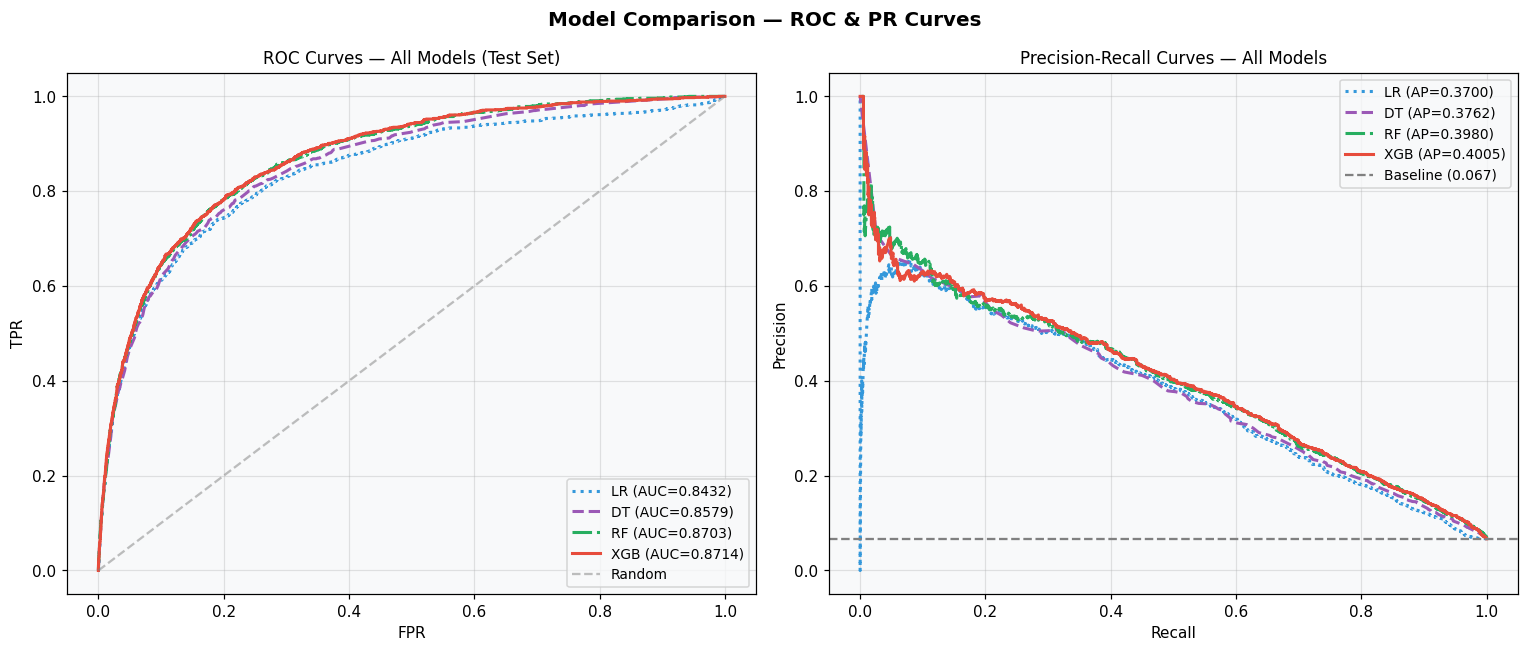

In [16]:
# ─── Overlay plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
model_configs = [
    (lr_best,  f'LR (AUC={auc_lr:.4f})',  PALETTE['neutral'],    ':'),
    (dt_best,  f'DT (AUC={auc_dt:.4f})',  PALETTE['highlight'],  '--'),
    (rf_best,  f'RF (AUC={auc_rf:.4f})',  '#27ae60',             '-.'),
    (xgb_best, f'XGB (AUC={auc_xgb:.4f})', PALETTE['default'],  '-'),
]
for model, label, color, ls in model_configs:
    proba = model.predict_proba(X_test)[:, 1]
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, linestyle=ls, label=label)
    # PR
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2, linestyle=ls,
                 label=f'{label.split("(")[0]}(AP={ap:.4f})')

axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5,label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — All Models (Test Set)')
axes[0].legend(fontsize=9)

axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models')
axes[1].legend(fontsize=9)

plt.suptitle('Model Comparison — ROC & PR Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_20_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


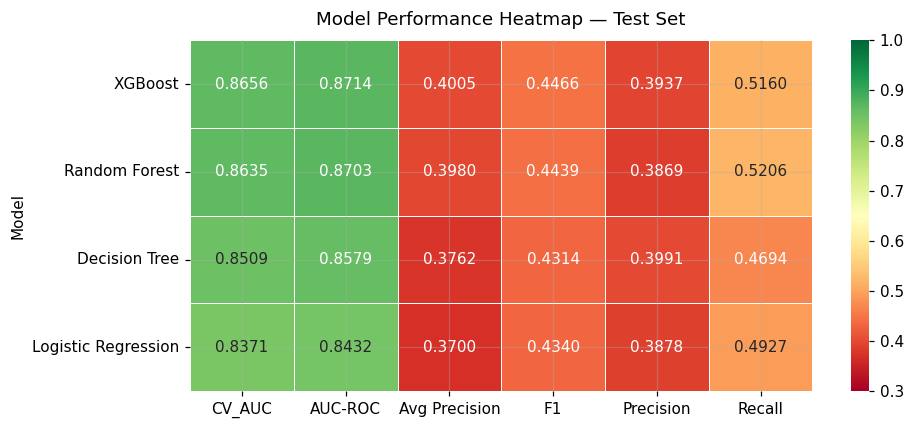

In [17]:
# ─── Comparison heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
metric_cols = ['CV_AUC', 'AUC-ROC', 'Avg Precision', 'F1', 'Precision', 'Recall']
hm_data = results_df.set_index('Model')[metric_cols]
sns.heatmap(hm_data, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.3, vmax=1.0, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('Model Performance Heatmap — Test Set', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('../reports/fig_21_model_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Lưu Best Model & SHAP (XGBoost)

In [18]:
# Best model là XGBoost (highest AUC-ROC)
best_model = xgb_best
joblib.dump(best_model, '../models/best_model.pkl')
print(f"Saved: models/best_model.pkl ({best_model_name})")

# Save tất cả models
joblib.dump(lr_best,  '../models/model_lr.pkl')
joblib.dump(dt_best,  '../models/model_dt.pkl')
joblib.dump(rf_best,  '../models/model_rf.pkl')
joblib.dump(xgb_best, '../models/model_xgb.pkl')
print("Saved: model_lr.pkl, model_dt.pkl, model_rf.pkl, model_xgb.pkl")

# Save results DataFrame
results_df.to_csv('../reports/model_results.csv', index=False)
print("Saved: reports/model_results.csv")

print()
print("=== FINAL SUMMARY ===")
print(results_df[['Model','CV_AUC','AUC-ROC','F1','Recall','Train_time_s']].to_string(index=False))


Saved: models/best_model.pkl (XGBoost)
Saved: model_lr.pkl, model_dt.pkl, model_rf.pkl, model_xgb.pkl
Saved: reports/model_results.csv

=== FINAL SUMMARY ===
              Model   CV_AUC  AUC-ROC       F1   Recall  Train_time_s
            XGBoost 0.865590 0.871358 0.446619 0.515957         126.6
      Random Forest 0.863480 0.870307 0.443878 0.520612         511.4
      Decision Tree 0.850853 0.857933 0.431408 0.469415          13.2
Logistic Regression 0.837136 0.843197 0.433968 0.492686         487.9
